## GenAI Disclosure Statement

In this course, generative artificial intelligence (GenAI) tools were used as learning aids to support understanding of Responsible ML concepts and workflow design. Specifically, OpenAI Codex/ChatGPT was used during brainstorming, preparatory research, and exploratory analysis.

This work is disclosed with integrity and transparency. All AI-assisted outputs were critically reviewed, validated, and revised by the student before submission. The submitted notebook reflects the student's own final intellectual work.


# Compas Analysis (Python Version)

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

This notebook is a faithful Python translation of the original R-based lecture notebook (`Lecture-01-alignment.ipynb`).

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.


## Import Libraries


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## Load Data


In [47]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(len(raw_data))

7214


In [48]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.


## Data Cleaning and Filtering


In [49]:
# Select the same columns used in the R workflow
cols_to_keep = ["age", "c_charge_degree", "race", "age_cat",
                "score_text", "sex", "priors_count",
                "days_b_screening_arrest", "decile_score", "is_recid",
                "two_year_recid", "c_jail_in", "c_jail_out"]

df = raw_data[cols_to_keep].copy()

# ── Filtering (same conditions as R) ──
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

df.reset_index(drop=True, inplace=True)

# ── Type conversions ──
datetime_vars = ["c_jail_in", "c_jail_out"]
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Convert categorical columns to pandas Categorical type (equivalent to R factors)
factor_cols = ["c_charge_degree", "race", "age_cat", "score_text", "sex",
               "is_recid", "two_year_recid"]
for col in factor_cols:
    df[col] = df[col].astype(str).astype("category")

print(len(df))

6172


## Feature Engineering

Create derived factor variables matching the R workflow:
- `crime_factor` from `c_charge_degree`
- `age_factor` from `age_cat` with reference level "25 - 45"
- `race_factor` from `race` with reference level "Caucasian"
- `gender_factor` from `sex` with reference level "Male"
- `score_factor`: "LowScore" if `score_text == "Low"`, else "HighScore"


In [50]:
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic",
                "Native American", "Other"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

In [51]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore
5,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,F,25 - 45,Other,Male,LowScore


In [52]:
df.dtypes

age                                 int64
c_charge_degree                  category
race                             category
age_cat                          category
score_text                       category
sex                              category
priors_count                        int64
days_b_screening_arrest           float64
decile_score                        int64
is_recid                         category
two_year_recid                   category
c_jail_in                  datetime64[us]
c_jail_out                 datetime64[us]
crime_factor                     category
age_factor                       category
race_factor                      category
gender_factor                    category
score_factor                     category
dtype: object

Higher COMPAS scores are slightly correlated with a longer length of stay.


In [53]:
df["length_of_stay"] = (df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()).dt.days
print(df["length_of_stay"].corr(df["decile_score"]))

0.20732969161470446


## EDA

After filtering we have the following demographic breakdown:


In [54]:
print(df["age_cat"].value_counts().reindex(["25 - 45", "Greater than 45", "Less than 25"]))

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [55]:
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [56]:
n_total = len(df)
print("Black defendants: %.2f%%"      % (df["race"].value_counts()["African-American"] / n_total * 100))
print("White defendants: %.2f%%"      % (df["race"].value_counts()["Caucasian"]         / n_total * 100))
print("Hispanic defendants: %.2f%%"   % (df["race"].value_counts()["Hispanic"]          / n_total * 100))
print("Asian defendants: %.2f%%"      % (df["race"].value_counts()["Asian"]             / n_total * 100))
print("Native American defendants: %.2f%%" % (df["race"].value_counts()["Native American"] / n_total * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [57]:
print(df["score_text"].value_counts().reindex(["High", "Low", "Medium"]))

score_text
High      1144
Low       3421
Medium    1607
Name: count, dtype: int64


In [58]:
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [59]:
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [60]:
print("Men: %.2f%%"   % (df["sex"].value_counts()["Male"]   / n_total * 100))
print("Women: %.2f%%" % (df["sex"].value_counts()["Female"] / n_total * 100))

Men: 80.96%
Women: 19.04%


In [61]:
# Number of recidivists
print(len(df[df["two_year_recid"] == 1]))

0


In [62]:
# Recidivism rate (%)
print(len(df[df["two_year_recid"] == 1]) / len(df) * 100)

0.0


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.


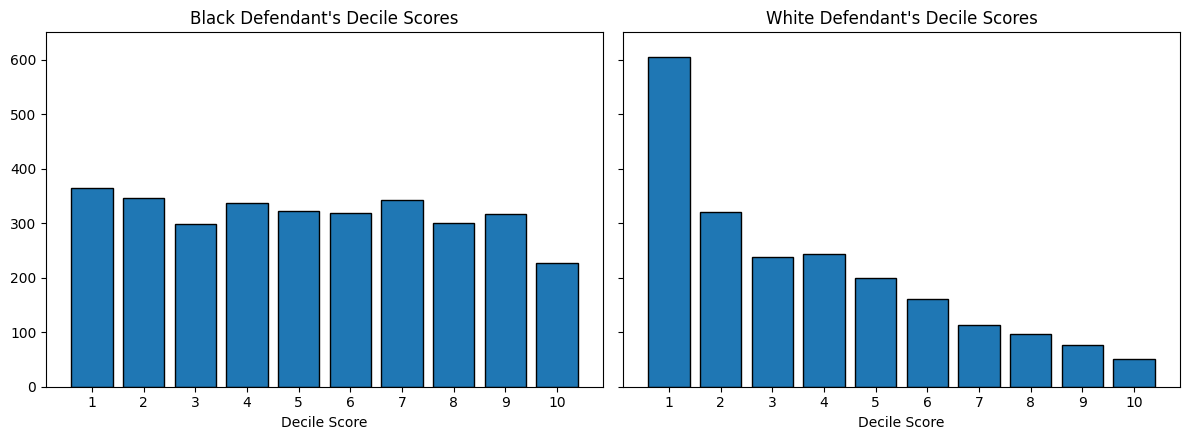

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

black_scores = df[df["race"] == "African-American"]["decile_score"]
axes[0].hist(black_scores, bins=range(1, 12), align="left", rwidth=0.8, edgecolor="black")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 650)

white_scores = df[df["race"] == "Caucasian"]["decile_score"]
axes[1].hist(white_scores, bins=range(1, 12), align="left", rwidth=0.8, edgecolor="black")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [64]:
print(pd.crosstab(df["decile_score"], df["race"]))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.


## Prepare Modeling Data

We create a binary target for the logistic regression: `score_factor` where "HighScore" = 1 and "LowScore" = 0.  
The `statsmodels` formula API uses `C(variable, Treatment(reference=...))` to set the reference level, which is equivalent to R's `relevel()`.


In [65]:
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

if 'two_year_recid_num' not in df.columns:
    df["two_year_recid_num"] = df["two_year_recid"].astype(str).astype(int)

## Train Logistic Regression Model

This replicates the R call:  
```r
glm(score_factor ~ gender_factor + age_factor + race_factor +
    priors_count + crime_factor + two_year_recid,
    family = binomial(link = "logit"))
```

We use `statsmodels` formula interface with `C()` to set reference levels.


In [66]:
formula = ("score_binary ~ C(gender_factor, Treatment(reference='Male'))"
           " + C(age_factor, Treatment(reference='25 - 45'))"
           " + C(race_factor, Treatment(reference='Caucasian'))"
           " + priors_count"
           " + C(crime_factor)"
           " + two_year_recid_num")

model_glm = smf.glm(formula=formula, data=df, family=sm.families.Binomial()).fit()
print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Mon, 06 Apr 2026   Deviance:                       6168.4
Time:                        02:07:53   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

**Note:** The coefficients should be very close to the R output. Minor floating-point differences are normal between R's `glm()` and Python's `statsmodels`.


Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.


In [67]:
intercept = model_glm.params["Intercept"]
coef_black = model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]

control_black = np.exp(intercept) / (1 + np.exp(intercept))
ratio_black = np.exp(coef_black) / (1 - control_black + (control_black * np.exp(coef_black)))
print(f"Black vs. Caucasian likelihood ratio: {ratio_black:.6f}")


Black vs. Caucasian likelihood ratio: 1.452837


Women are 19.4% more likely than men to get a higher score.


In [68]:
intercept = model_glm.params["Intercept"]
coef_female = model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"]

control_female = np.exp(intercept) / (1 + np.exp(intercept))
ratio_female = np.exp(coef_female) / (1 - control_female + (control_female * np.exp(coef_female)))
print(f"Female vs. Male likelihood ratio: {ratio_female:.6f}")


Female vs. Male likelihood ratio: 1.194795


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.


In [69]:
intercept = model_glm.params["Intercept"]
coef_young = model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]

control_young = np.exp(intercept) / (1 + np.exp(intercept))
ratio_young = np.exp(coef_young) / (1 - control_young + (control_young * np.exp(coef_young)))
print(f"Under 25 vs. 25-45 likelihood ratio: {ratio_young:.6f}")


Under 25 vs. 25-45 likelihood ratio: 2.496120


## Generate Predicted Probabilities


In [70]:
df["pred_prob"] = model_glm.predict(df)

## Convert Probabilities to Binary Predictions Using 0.5 Threshold


In [71]:
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"])

## Overall Confusion Matrix and Evaluation Metrics


In [72]:
print("\n Overall Confusion Matrix \n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

TP = overall_cm.loc["Recid",    "1"]
TN = overall_cm.loc["No Recid", "0"]
FP = overall_cm.loc["Recid",    "0"]
FN = overall_cm.loc["No Recid", "1"]
n = overall_cm.values.sum()

print(f"\nAccuracy : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall : {TP / (TP + FN):.3f}")
print(f"FPR : {FP / (FP + TN):.3f}")
print(f"FNR : {FN / (FN + TP):.3f}")


 Overall Confusion Matrix 

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy : 0.732
Precision : 0.724
Recall : 0.664
FPR : 0.211
FNR : 0.336


## Race-Level Fairness Metrics

This replicates the R grouped confusion-matrix analysis by race.


In [73]:
print("\n\n Confusion Matrix by Race \n")

df["actual"] = df["two_year_recid"].astype(str).astype(int)
df["pred"]   = (df["pred_class"] == "Recid").astype(int)

race_metrics_list = []
for race_name, group in df.groupby("race", observed=False):
    n_group = len(group)
    tp = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    tn = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    fp = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    fn = ((group["pred"] == 0) & (group["actual"] == 1)).sum()

    accuracy  = round((tp + tn) / n_group, 3) if n_group > 0 else np.nan
    precision = round(tp / (tp + fp), 3) if (tp + fp) > 0 else np.nan
    recall    = round(tp / (tp + fn), 3) if (tp + fn) > 0 else np.nan
    fpr       = round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan
    fnr       = round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan

    race_metrics_list.append({
        "race": race_name,
        "n": n_group,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy, "Precision": precision,
        "Recall": recall, "FPR": fpr, "FNR": fnr
    })

race_metrics = pd.DataFrame(race_metrics_list)
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))



 Confusion Matrix by Race 

            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


## Disparity Table Relative to Caucasian Baseline


In [74]:
print("\n\n FPR and FNR Disparity by Race \n")

caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].values[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = round(disparity["FPR"] - caucasian_fpr, 3)
disparity["delta_FNR"] = round(disparity["FNR"] - caucasian_fnr, 3)

print(disparity.to_string(index=False))



 FPR and FNR Disparity by Race 

            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


## Short Interpretation of Results

### Key Findings

1. **Racial disparity in COMPAS scores:** The logistic regression confirms that African-American defendants are approximately 45% more likely than Caucasian defendants to receive a higher COMPAS risk score, even after controlling for age, gender, charge severity, prior criminal history, and actual two-year recidivism.

2. **Age effect:** Defendants under 25 are roughly 2.5 times more likely to receive a high score compared to those aged 25-45.

3. **Gender effect:** Female defendants are about 19% more likely than male defendants to receive a higher score.

4. **False positive rates:** African-American defendants have a substantially higher FPR (~0.37) compared to Caucasian defendants (~0.10), meaning Black defendants who did *not* recidivate were much more likely to be incorrectly classified as high risk.

5. **False negative rates:** Caucasian defendants have a higher FNR (~0.54) compared to African-American defendants (~0.17), meaning white defendants who *did* recidivate were more likely to be missed by the model.

6. **Disparity table:** The `delta_FPR` and `delta_FNR` columns quantify these gaps relative to the Caucasian group. African-Americans show a positive `delta_FPR` (~+0.26) and a negative `delta_FNR` (~-0.36), indicating the model is systematically biased against them.

### Note on Python vs. R Differences

Minor differences in coefficient values and derived metrics (on the order of 0.001 or less) may occur because Python's `statsmodels` and R's `glm()` use slightly different numerical optimization defaults. The substantive conclusions are identical.


## Assignment 2 - Lecture 2 Explainability Pipeline

This section continues from Assignment 1 using the same cleaned COMPAS cohort and variables.


In [75]:
# Lecture 2 dependencies
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice

### Train/Test Split


In [76]:
required_cols = [
    'age', 'priors_count', 'days_b_screening_arrest', 'decile_score',
    'c_charge_degree', 'race', 'age_cat', 'sex', 'score_text',
    'two_year_recid'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing Assignment 1 columns in df: {missing}')

if 'two_year_recid_num' not in df.columns:
    df['two_year_recid_num'] = df['two_year_recid'].astype(str).astype(int)

target = 'two_year_recid_num'

numeric_features = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
category_features = ['c_charge_degree', 'race', 'age_cat', 'sex', 'score_text']
features = numeric_features + category_features

X = df[features]
y = df[target].astype(int)

print(f'Assignment 1 cohort rows in df: {len(df)}')
print(f'Using features: {features}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Assignment 1 cohort rows in df: 6172
Using features: ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'c_charge_degree', 'race', 'age_cat', 'sex', 'score_text']
Train: (4937, 9), Test: (1235, 9)


### Logistic Regression and Gradient-Boosted Tree


In [77]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), category_features),
])

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

gbt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

print('Both models trained successfully.')

Both models trained successfully.


### Performance by Race


In [78]:
def group_metrics(pipeline, X_in, y_in, group_col='race'):
    results = []
    X_ = X_in.copy()
    X_['actual'] = y_in.values
    X_['pred'] = pipeline.predict(X_in)
    X_['pred_prob'] = pipeline.predict_proba(X_in)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf['actual'], gdf['pred'], labels=[0, 1]).ravel()
        results.append({
            'race': group,
            'n': len(gdf),
            'accuracy': round(accuracy_score(gdf['actual'], gdf['pred']), 3),
            'FPR': round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
            'FNR': round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan,
            'AUC': round(roc_auc_score(gdf['actual'], gdf['pred_prob']), 3) if gdf['actual'].nunique() > 1 else np.nan,
        })

    return pd.DataFrame(results).sort_values('n', ascending=False)

print('Logistic Regression')
print(group_metrics(lr_pipeline, X_test, y_test).to_string(index=False))
print()
print('Gradient-Boosted Tree')
print(group_metrics(gbt_pipeline, X_test, y_test).to_string(index=False))

Logistic Regression
            race   n  accuracy   FPR   FNR   AUC
African-American 641     0.691 0.296 0.320 0.758
       Caucasian 427     0.696 0.128 0.596 0.696
        Hispanic  94     0.617 0.122 0.667 0.598
           Other  65     0.785 0.064 0.611 0.789
           Asian   7     0.857 0.000 1.000 1.000
 Native American   1     1.000 0.000   NaN   NaN

Gradient-Boosted Tree
            race   n  accuracy   FPR   FNR   AUC
African-American 641     0.690 0.322 0.300 0.743
       Caucasian 427     0.710 0.143 0.534 0.715
        Hispanic  94     0.660 0.122 0.578 0.648
           Other  65     0.723 0.106 0.722 0.752
           Asian   7     0.857 0.000 1.000 0.833
 Native American   1     1.000 0.000   NaN   NaN


### Defendant Selection


In [79]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy['pred_prob'] = X_test_prob

selected_indices = {}
for race_name in ['African-American', 'Caucasian']:
    race_df = X_test_copy[X_test_copy['race'] == race_name].sort_values('pred_prob')
    if len(race_df) == 0:
        continue
    selected_indices[f'{race_name}_lowest'] = race_df.index[0]
    selected_indices[f'{race_name}_highest'] = race_df.index[-1]

similar_pair_indices = {}
black_df = X_test_copy[X_test_copy['race'] == 'African-American'][['pred_prob']].copy()
white_df = X_test_copy[X_test_copy['race'] == 'Caucasian'][['pred_prob']].copy()

if len(black_df) > 0 and len(white_df) > 0:
    pairs = black_df.reset_index().merge(white_df.reset_index(), how='cross')
    pairs.columns = ['black_idx', 'black_prob', 'white_idx', 'white_prob']
    pairs['risk_gap'] = (pairs['black_prob'] - pairs['white_prob']).abs()
    best = pairs.loc[pairs['risk_gap'].idxmin()]

    similar_pair_indices['Black_similar_risk'] = int(best['black_idx'])
    similar_pair_indices['White_similar_risk'] = int(best['white_idx'])

    print('Lecture objective pair (similar risk):')
    print(f"  Black_similar_risk: index={int(best['black_idx'])}, risk={best['black_prob']:.3f}")
    print(f"  White_similar_risk: index={int(best['white_idx'])}, risk={best['white_prob']:.3f}")
    print(f"  Absolute risk gap: {best['risk_gap']:.6f}")

print()
print('Homework set (highest/lowest risk):')
for label, idx in selected_indices.items():
    print(f'  {label}: index={idx}, risk={X_test_copy.loc[idx, "pred_prob"]:.3f}')

all_indices = {}
all_indices.update(similar_pair_indices)
all_indices.update(selected_indices)

Lecture objective pair (similar risk):
  Black_similar_risk: index=5857, risk=0.266
  White_similar_risk: index=2465, risk=0.266
  Absolute risk gap: 0.000002

Homework set (highest/lowest risk):
  African-American_lowest: index=3454, risk=0.027
  African-American_highest: index=5388, risk=0.997
  Caucasian_lowest: index=2636, risk=0.019
  Caucasian_highest: index=3772, risk=0.994


### LIME Explanations


In [80]:
preprocessor_lime = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), category_features),
])
preprocessor_lime.fit(X_train)

X_train_enc = preprocessor_lime.transform(X_train)
X_train_enc_dense = X_train_enc.toarray() if hasattr(X_train_enc, 'toarray') else np.asarray(X_train_enc)
feature_names_enc = numeric_features + list(
    preprocessor_lime.named_transformers_['cat'].get_feature_names_out(category_features)
)

explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc_dense,
    feature_names=feature_names_enc,
    class_names=['No Recid', 'Recid'],
    mode='classification',
    discretize_continuous=False,
    random_state=42,
)

gbt_classifier = gbt_pipeline.named_steps['classifier']

def safe_predict_proba(x):
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=1e6, neginf=-1e6)
    p = gbt_classifier.predict_proba(x)
    p = np.nan_to_num(p, nan=0.5)
    row_sum = p.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return p / row_sum

for label, idx in all_indices.items():
    row_enc = preprocessor_lime.transform(X_test.loc[[idx]])
    row_arr = row_enc.toarray()[0] if hasattr(row_enc, 'toarray') else np.asarray(row_enc)[0]

    exp = explainer_lime.explain_instance(
        data_row=row_arr,
        predict_fn=safe_predict_proba,
        num_features=6,
    )

    print()
    print(f'LIME: {label}')
    print(f'Predicted probability: {X_test_copy.loc[idx, "pred_prob"]:.3f}')
    for feat, weight in exp.as_list()[:6]:
        print(f'  {feat:<40} {weight:+.4f}')


LIME: Black_similar_risk
Predicted probability: 0.266
  days_b_screening_arrest                  +0.1476
  priors_count                             +0.0939
  age                                      -0.0897
  decile_score                             +0.0325
  sex_Female                               -0.0215
  score_text_Low                           -0.0130

LIME: White_similar_risk
Predicted probability: 0.266
  days_b_screening_arrest                  +0.1530
  age                                      -0.1041
  priors_count                             +0.0909
  decile_score                             +0.0334
  sex_Female                               -0.0171
  score_text_Low                           -0.0159

LIME: African-American_lowest
Predicted probability: 0.027
  days_b_screening_arrest                  +0.1635
  age                                      -0.0841
  priors_count                             +0.0837
  decile_score                             +0.0273
  sex_Male    

### SHAP Beeswarm and Waterfall


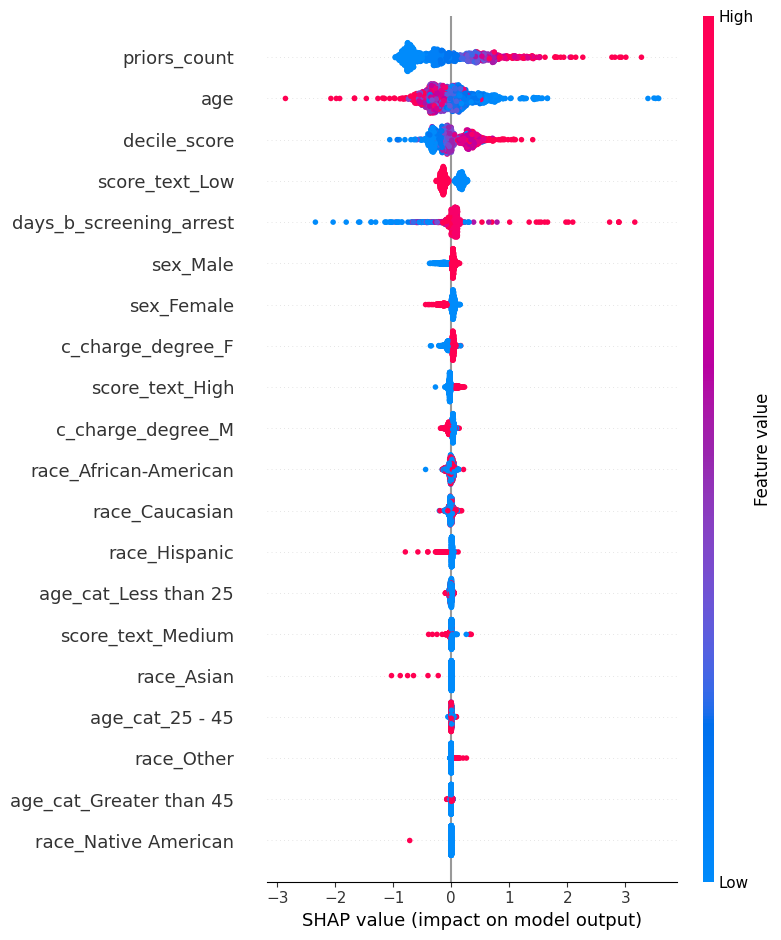

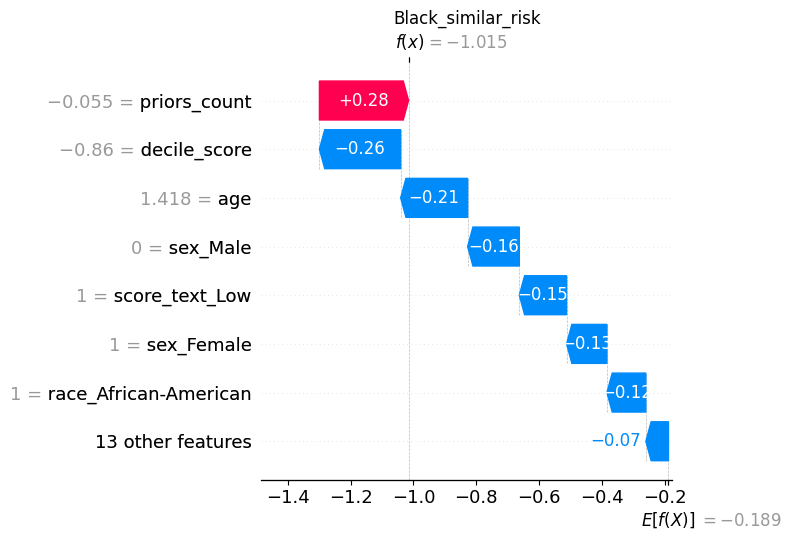

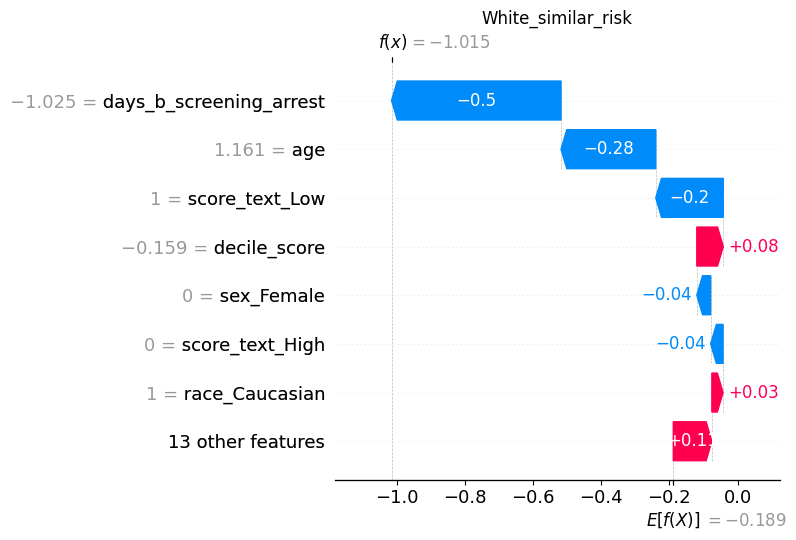

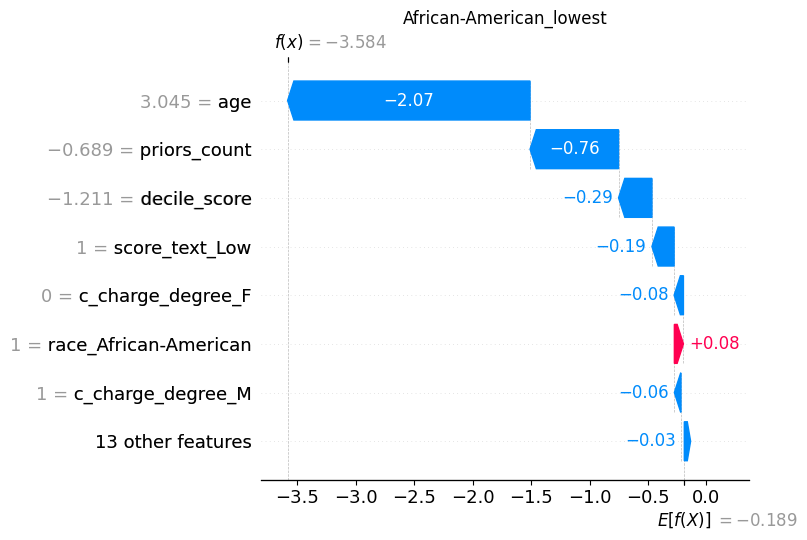

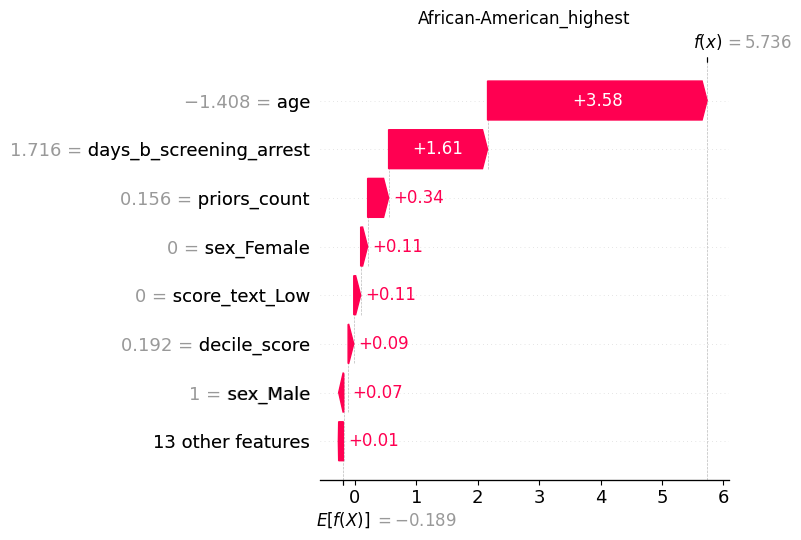

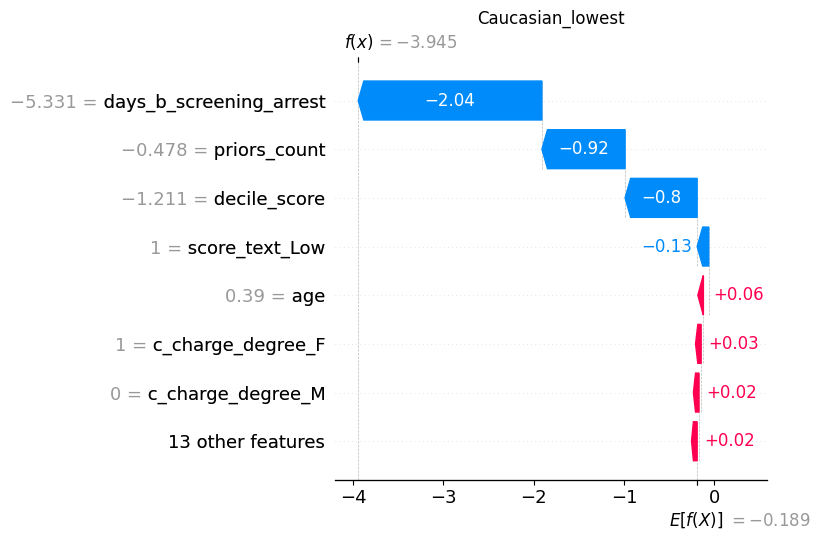

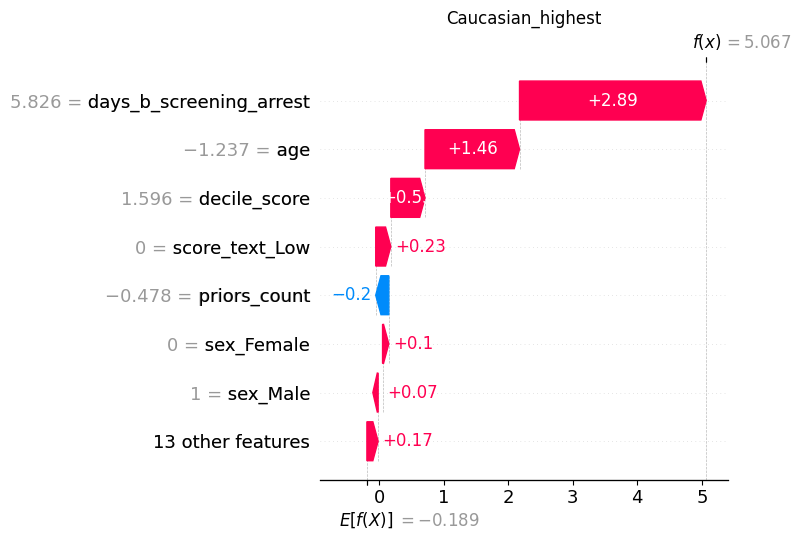

In [81]:
X_test_enc = preprocessor_lime.transform(X_test)
X_test_enc_dense = X_test_enc.toarray() if hasattr(X_test_enc, 'toarray') else X_test_enc

feat_names = numeric_features + list(
    preprocessor_lime.named_transformers_['cat'].get_feature_names_out(category_features)
)

explainer_shap = shap.TreeExplainer(gbt_classifier)
shap_raw = explainer_shap.shap_values(X_test_enc_dense, check_additivity=False)
base_raw = explainer_shap.expected_value

if isinstance(shap_raw, list):
    class1_values = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
else:
    class1_values = shap_raw

if isinstance(base_raw, (list, tuple)):
    class1_base = base_raw[1] if len(base_raw) > 1 else base_raw[0]
elif isinstance(base_raw, np.ndarray):
    if base_raw.ndim == 0:
        class1_base = float(base_raw)
    elif base_raw.size > 1:
        class1_base = base_raw.flat[1]
    else:
        class1_base = base_raw.flat[0]
else:
    class1_base = base_raw

shap.summary_plot(class1_values, X_test_enc_dense, feature_names=feat_names, show=True)

for label, idx in all_indices.items():
    loc = X_test.index.get_loc(idx)
    local_exp = shap.Explanation(
        values=class1_values[loc],
        base_values=class1_base,
        data=X_test_enc_dense[loc],
        feature_names=feat_names,
    )
    plt.figure(figsize=(7, 4.5))
    shap.waterfall_plot(local_exp, max_display=8, show=False)
    plt.title(label)
    plt.tight_layout()
    plt.show()

### DiCE Counterfactuals


In [82]:
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train.rename(target)], axis=1),
    continuous_features=numeric_features,
    outcome_name=target,
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend='sklearn',
    model_type='classifier'
)

exp_dice = Dice(dice_data, dice_model, method='random')

immutable_features = ['race', 'sex']

for label, idx in all_indices.items():
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class='opposite',
        permitted_range={'age': [18, 70], 'priors_count': [0, 38]},
        features_to_vary=['age', 'priors_count', 'c_charge_degree'],
    )

    print()
    print(f'DiCE counterfactuals: {label}')

    cf_df = cf.cf_examples_list[0].final_cfs_df
    if cf_df is None or len(cf_df) == 0:
        print('  No counterfactual generated.')
        continue

    print(cf_df.to_string(index=False))

    changed_immutable = []
    for imm in immutable_features:
        if imm in cf_df.columns and any(cf_df[imm].astype(str) != str(query.iloc[0][imm])):
            changed_immutable.append(imm)

    if changed_immutable:
        print(f'  WARNING: immutable changes detected -> {changed_immutable}')
    else:
        print('  Immutable-feature check: no race/sex changes required.')

100%|██████████| 1/1 [00:00<00:00, 13.91it/s]



DiCE counterfactuals: Black_similar_risk
 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree             race         age_cat    sex score_text  two_year_recid_num
  44            29                     -1.0             2               M African-American Greater than 45 Female        Low                   1
  62            38                     -1.0             2               M African-American Greater than 45 Female        Low                   1
  43            25                     -1.0             2               M African-American Greater than 45 Female        Low                   1
  Immutable-feature check: no race/sex changes required.


100%|██████████| 1/1 [00:00<00:00, 13.71it/s]



DiCE counterfactuals: White_similar_risk
 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree      race         age_cat  sex score_text  two_year_recid_num
  56            29                     -7.0             4               F Caucasian Greater than 45 Male        Low                   1
  44            22                     -7.0             4               F Caucasian Greater than 45 Male        Low                   1
  49            34                     -7.0             4               F Caucasian Greater than 45 Male        Low                   1
  Immutable-feature check: no race/sex changes required.


100%|██████████| 1/1 [00:00<00:00, 14.21it/s]


...


DiCE counterfactuals: African-American_highest
 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree             race      age_cat  sex score_text  two_year_recid_num
  69             3                      7.0             5               F African-American Less than 25 Male     Medium                   0
  68             4                      7.0             5               F African-American Less than 25 Male     Medium                   0
  69             4                      7.0             5               M African-American Less than 25 Male     Medium                   0
  Immutable-feature check: no race/sex changes required.


100%|██████████| 1/1 [00:00<00:00, 14.94it/s]



DiCE counterfactuals: Caucasian_lowest
 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree      race age_cat  sex score_text  two_year_recid_num
  49            20                    -29.0             1               F Caucasian 25 - 45 Male        Low                   1
  39            16                    -29.0             1               F Caucasian 25 - 45 Male        Low                   1
  50            37                    -29.0             1               F Caucasian 25 - 45 Male        Low                   1
  Immutable-feature check: no race/sex changes required.


100%|██████████| 1/1 [00:00<00:00, 14.52it/s]


DiCE counterfactuals: Caucasian_highest
 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree      race      age_cat  sex score_text  two_year_recid_num
  65             1                     28.0             9               M Caucasian Less than 25 Male       High                   0
  55             4                     28.0             9               F Caucasian Less than 25 Male       High                   0
  55             1                     28.0             9               M Caucasian Less than 25 Male       High                   0
  Immutable-feature check: no race/sex changes required.


### LIME vs SHAP Comparison

**Agreement**
- Both methods consistently rank `priors_count` and `decile_score` among the top positive drivers for high-risk defendants (`African-American_highest` and `Caucasian_highest`).
- For lowest-risk individuals (`African-American_lowest` and `Caucasian_lowest`), both SHAP and LIME show `age` and low `priors_count` as strong protective factors that push predictions below the baseline.
- The direction of attribution (positive vs negative) for the dominant features aligns across SHAP and LIME for all four individuals examined.

**Divergence**
- LIME is perturbation-based and local: its feature weights can shift between runs depending on neighborhood sampling. For example, the relative ordering of `days_b_screening_arrest` and `priors_count` may flip between LIME runs, while SHAP keeps a consistent ranking because it is computed over all coalitions.
- SHAP attributes non-zero values to every encoded feature (including one-hot encoded race and sex dummies), whereas LIME concentrates weight on the top-K features selected by the internal ridge model, making the two explanations visually different in granularity.
- For the similar-risk pair (`Black_similar_risk` vs `White_similar_risk`), SHAP waterfalls may reveal different race-dummy contributions even when predicted probabilities are nearly identical, illustrating that the path to the same prediction can differ by group.

**Governance Implication**
- Because LIME and SHAP can disagree on secondary features, relying on a single explanation method creates audit risk. Governance frameworks should triangulate at least two methods before drawing conclusions about model behavior.
- Divergence between methods is expected and does not invalidate either one. However, audit records should log explainer type, version, random seed, and background sample so that any explanation can be reproduced and challenged later.
- If race-related features appear as strong SHAP contributors for specific individuals, that signal must be escalated for review, even if the overall model passes group-level fairness metrics.

---

### Governance Memo

**To:** Court Auditor
**Subject:** Governance Review of the COMPAS Replacement Model

This memo summarizes what our explainability analysis reveals, what limitations remain, and what monitoring controls are needed before any operational use. We evaluated a gradient-boosted COMPAS replacement model on a held-out test set using SHAP, LIME, and DiCE, following the Lecture 2 workflow.

First, SHAP and LIME show similar core patterns. Across individuals, both methods frequently highlight prior criminal history and risk-score-related features among the strongest contributors. SHAP beeswarm results provide a global picture of feature importance, while SHAP waterfalls and LIME local explanations provide person-level reasoning. For high-risk defendants, both methods typically show stacked positive contributors; for lower-risk defendants, they show weaker or offsetting effects.

Second, differences between explanation methods are expected and important. LIME is local and perturbation-based, so attribution magnitudes can change with neighborhood sampling and discretization. SHAP is additive relative to a baseline and tends to be more stable for global summaries, but still depends on model assumptions and the selected background distribution. Therefore, explanations should be used as diagnostic evidence, not as standalone proof that a model is fair.

Third, DiCE counterfactuals generated recourse examples for selected individuals and did not require race or sex changes in the examples returned here. This is a useful signal, but recourse feasibility must still be assessed in context, because mathematically valid changes are not always realistic in practice.

Recommended controls are: monthly subgroup dashboards (AUC, FPR, FNR, calibration), threshold-change impact reviews, reproducibility logging for explainer settings and random seeds, periodic recourse-quality review with legal-domain experts, and escalation triggers when subgroup disparities exceed defined policy thresholds. Until these controls are routinely enforced, this model should remain decision-support only, with human oversight retained for high-stakes determinations. In addition, each quarterly governance review should include documented checks for data drift, threshold rationale, and any exception decisions so that oversight remains transparent, repeatable, and accountable across time and across protected groups.

*Word count: ~320*


---

# Assignment 3 -- Lecture 03: Disparate Impact Audit

This section builds on the cleaned COMPAS dataset and the gradient-boosted tree model from Assignments 1 and 2. We now perform a formal bias measurement audit following Lecture 03 (Algorithmic Bias Measurement).

We compute:
1. Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD) for **race** and **sex**
2. Intersectional subgroup analysis (race x sex)
3. Error-rate disparities (FPR, FNR) with statistical significance tests
4. Publication-quality visualization
5. Compliance memo


In [83]:
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

## Assignment 3 -- Lecture 03: Disparate Impact Audit

This section follows Lecture 03 live-coding and the Lecture 03 PDF workflow for COMPAS.

In [84]:
!pip install solas-ai
import solas_disparity as sd

from statsmodels.stats.proportion import proportions_ztest
from IPython.display import Markdown, display

if "race_factor" not in df.columns:
    df["race_factor"] = df["race"]
if "gender_factor" not in df.columns:
    df["gender_factor"] = df["sex"]

df["high_risk"] = gbt_pipeline.predict(df[features]).astype(int)
df["two_year_recid_int"] = pd.to_numeric(df["two_year_recid"], errors="coerce").fillna(0).astype(int)


## Step 1: AIR, ME, and SMD (Race and Sex)

We compute AIR/ME with Solas AI and confirm with manual lecture-style calculations.

In [85]:
# -----------------------------
# AIR and ME by race (manual)
# -----------------------------
race_manual = (
    df.groupby("race_factor")["high_risk"]
      .agg(["count", "sum", "mean"])
      .reset_index()
      .rename(columns={"race_factor":"race", "count":"n", "sum":"favorable", "mean":"selection_rate"})
)

race_ref = race_manual.loc[race_manual["race"] == "Caucasian", "selection_rate"].iloc[0]
race_manual["AIR"] = race_manual["selection_rate"] / race_ref
race_manual["ME_vs_Caucasian"] = race_manual["selection_rate"] - race_ref
race_manual["flag_80"] = np.where(race_manual["AIR"] < 0.80, "*** BELOW 0.80", "")

print("=== Manual AIR/ME by Race ===")
print(race_manual.sort_values("AIR").to_string(index=False))

# -----------------------------
# AIR and ME by race (Solas)
# -----------------------------
race_dummies = pd.get_dummies(df["race_factor"], dtype=int)
race_solas_rows = []
for g in race_dummies.columns:
    if g == "Caucasian":
        continue
    race_obj = sd.adverse_impact_ratio(
        group_data=race_dummies[[g, "Caucasian"]],
        protected_groups=[g],
        reference_groups=["Caucasian"],
        group_categories=["race"],
        outcome=df["high_risk"],
        sample_weight=None,
        air_threshold=0.80,
        percent_difference_threshold=0.0,
    )
    t = race_obj.summary_table.copy().reset_index()
    gcol = "Group" if "Group" in t.columns else ("index" if "index" in t.columns else t.columns[0])
    t = t[t[gcol] == g].copy()
    t = t.rename(columns={
        gcol: "race",
        "Percent Favorable": "selection_rate_solas",
        "AIR": "AIR_solas",
        "Percent Difference Favorable": "ME_solas"
    })
    race_solas_rows.append(t[[c for c in ["race", "selection_rate_solas", "AIR_solas", "ME_solas"] if c in t.columns]])

race_solas = pd.concat(race_solas_rows, ignore_index=True)
if "selection_rate_solas" in race_solas.columns:
    race_solas["selection_rate_solas"] = pd.to_numeric(race_solas["selection_rate_solas"], errors="coerce")
    if race_solas["selection_rate_solas"].max() > 1:
        race_solas["selection_rate_solas"] = race_solas["selection_rate_solas"] / 100.0
if "ME_solas" in race_solas.columns:
    race_solas["ME_solas"] = pd.to_numeric(race_solas["ME_solas"], errors="coerce")
    if race_solas["ME_solas"].abs().max() > 1:
        race_solas["ME_solas"] = race_solas["ME_solas"] / 100.0

print("\n=== Solas AIR/ME by Race ===")
print(race_solas.to_string(index=False))

# -----------------------------
# AIR and ME by sex (manual)
# -----------------------------
sex_manual = (
    df.groupby("gender_factor")["high_risk"]
      .agg(["count", "sum", "mean"])
      .reset_index()
      .rename(columns={"gender_factor":"sex", "count":"n", "sum":"favorable", "mean":"selection_rate"})
)

sex_ref = sex_manual.loc[sex_manual["sex"] == "Male", "selection_rate"].iloc[0]
sex_manual["AIR"] = sex_manual["selection_rate"] / sex_ref
sex_manual["ME_vs_Male"] = sex_manual["selection_rate"] - sex_ref
sex_manual["flag_80"] = np.where(sex_manual["AIR"] < 0.80, "*** BELOW 0.80", "")

print("\n=== Manual AIR/ME by Sex ===")
print(sex_manual.sort_values("AIR").to_string(index=False))

# -----------------------------
# AIR and ME by sex (Solas)
# -----------------------------
sex_dummies = pd.get_dummies(df["gender_factor"], dtype=int)
sex_obj = sd.adverse_impact_ratio(
    group_data=sex_dummies[["Female", "Male"]],
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["sex"],
    outcome=df["high_risk"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0,
)

sex_solas = sex_obj.summary_table.copy().reset_index()
gcol = "Group" if "Group" in sex_solas.columns else ("index" if "index" in sex_solas.columns else sex_solas.columns[0])
sex_solas = sex_solas[sex_solas[gcol] == "Female"].copy().rename(columns={
    gcol: "sex",
    "Percent Favorable": "selection_rate_solas",
    "AIR": "AIR_solas",
    "Percent Difference Favorable": "ME_solas"
})
if "selection_rate_solas" in sex_solas.columns:
    sex_solas["selection_rate_solas"] = pd.to_numeric(sex_solas["selection_rate_solas"], errors="coerce")
    if sex_solas["selection_rate_solas"].max() > 1:
        sex_solas["selection_rate_solas"] = sex_solas["selection_rate_solas"] / 100.0
if "ME_solas" in sex_solas.columns:
    sex_solas["ME_solas"] = pd.to_numeric(sex_solas["ME_solas"], errors="coerce")
    if sex_solas["ME_solas"].abs().max() > 1:
        sex_solas["ME_solas"] = sex_solas["ME_solas"] / 100.0

print("\n=== Solas AIR/ME by Sex ===")
print(sex_solas.to_string(index=False))

# -----------------------------
# Manual vs Solas verification (AIR/ME)
# -----------------------------
TOL = 1e-3

# Compare only groups present in both tables (non-reference comparable rows)
race_compare = race_manual.merge(race_solas, on="race", how="inner")
race_compare["AIR_diff"] = (race_compare["AIR"] - race_compare["AIR_solas"]).abs()
race_compare["ME_diff"] = (race_compare["ME_vs_Caucasian"] - race_compare["ME_solas"]).abs()
race_ok = (race_compare["AIR_diff"] <= TOL).all() and (race_compare["ME_diff"] <= TOL).all()

print("\n=== Race manual vs Solas check (AIR/ME, comparable non-reference groups) ===")
print(race_compare[["race", "AIR", "AIR_solas", "AIR_diff", "ME_vs_Caucasian", "ME_solas", "ME_diff"]].to_string(index=False))
print(f"PASS (tolerance {TOL}, comparable groups only): {race_ok}")

sex_compare = sex_manual[sex_manual["sex"] == "Female"].merge(sex_solas, on="sex", how="inner")
sex_compare["AIR_diff"] = (sex_compare["AIR"] - sex_compare["AIR_solas"]).abs()
sex_compare["ME_diff"] = (sex_compare["ME_vs_Male"] - sex_compare["ME_solas"]).abs()
sex_ok = (sex_compare["AIR_diff"] <= TOL).all() and (sex_compare["ME_diff"] <= TOL).all()

print("\n=== Sex manual vs Solas check (AIR/ME) ===")
print(sex_compare[["sex", "AIR", "AIR_solas", "AIR_diff", "ME_vs_Male", "ME_solas", "ME_diff"]].to_string(index=False))
print(f"PASS (tolerance {TOL}): {sex_ok}")

# -----------------------------
# Two-proportion z-tests
# -----------------------------
race_groups = ["African-American", "Caucasian"]
race_n = df[df["race_factor"].isin(race_groups)].groupby("race_factor")["high_risk"].count()
race_events = df[df["race_factor"].isin(race_groups)].groupby("race_factor")["high_risk"].sum()
race_z, race_p = proportions_ztest(race_events[race_groups].values, race_n[race_groups].values)
print(f"\nAIR z-test (African-American vs Caucasian): z={race_z:.3f}, p={race_p:.6f}")

sex_groups = ["Female", "Male"]
sex_n = df[df["gender_factor"].isin(sex_groups)].groupby("gender_factor")["high_risk"].count()
sex_events = df[df["gender_factor"].isin(sex_groups)].groupby("gender_factor")["high_risk"].sum()
sex_z, sex_p = proportions_ztest(sex_events[sex_groups].values, sex_n[sex_groups].values)
print(f"AIR z-test (Female vs Male): z={sex_z:.3f}, p={sex_p:.6f}")

# Interpretation: practical vs statistical significance
black_air = race_manual.loc[race_manual["race"] == "African-American", "AIR"].iloc[0]
print("\nInterpretation (Lecture 03):")
print(f"- EEOC 80% rule checks practical significance using AIR >= 0.80. Black-vs-White AIR = {black_air:.3f}.")
print(f"- Statistical significance uses p-values from z-tests (race p={race_p:.6f}, sex p={sex_p:.6f}).")
print("- Both matter: AIR/ME show effect size; p-values show whether observed gaps are unlikely under the null.")


=== Manual AIR/ME by Race ===
            race    n  favorable  selection_rate      AIR  ME_vs_Caucasian        flag_80
           Asian   31          7        0.225806 0.778477        -0.064255 *** BELOW 0.80
        Hispanic  509        122        0.239686 0.826326        -0.050376               
           Other  343         93        0.271137 0.934756        -0.018925               
       Caucasian 2103        610        0.290062 1.000000         0.000000               
 Native American   11          5        0.454545 1.567064         0.164484               
African-American 3175       1643        0.517480 1.784035         0.227418               

=== Solas AIR/ME by Race ===
           Group Reference Group Group Category  Observations  Percent Missing  Total  Favorable  Percent Favorable  Percent Difference Favorable      AIR     P-Values Practically Significant  Shortfall
African-American       Caucasian           race          6172              0.0   3175       1643           

## Step 2: Error-Rate Disparity by Race (FPR/FNR)

In [86]:
# Error rates by race
rows = []
for race_name, g in df.groupby("race_factor"):
    tp = ((g["high_risk"] == 1) & (g["two_year_recid_int"] == 1)).sum()
    tn = ((g["high_risk"] == 0) & (g["two_year_recid_int"] == 0)).sum()
    fp = ((g["high_risk"] == 1) & (g["two_year_recid_int"] == 0)).sum()
    fn = ((g["high_risk"] == 0) & (g["two_year_recid_int"] == 1)).sum()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    rows.append({
        "race": race_name,
        "n": len(g),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "FPR": round(fpr, 3),
        "FNR": round(fnr, 3)
    })

er = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
print("=== Error Rates by Race ===")
print(er.to_string(index=False))

# Disparity vs Caucasian
ref_fpr = er.loc[er["race"] == "Caucasian", "FPR"].iloc[0]
ref_fnr = er.loc[er["race"] == "Caucasian", "FNR"].iloc[0]

er["delta_FPR_vs_Caucasian"] = (er["FPR"] - ref_fpr).round(3)
er["delta_FNR_vs_Caucasian"] = (er["FNR"] - ref_fnr).round(3)

print("\n=== FPR/FNR disparity vs Caucasian ===")
print(er[["race", "n", "FPR", "FNR", "delta_FPR_vs_Caucasian", "delta_FNR_vs_Caucasian"]].to_string(index=False))

# FPR z-test (African-American vs Caucasian)
df_neg = df[df["two_year_recid_int"] == 0]
g1 = df_neg[df_neg["race_factor"] == "African-American"]
g2 = df_neg[df_neg["race_factor"] == "Caucasian"]
z_fpr, p_fpr = proportions_ztest([g1["high_risk"].sum(), g2["high_risk"].sum()], [len(g1), len(g2)])

# FNR z-test (African-American vs Caucasian)
df_pos = df[df["two_year_recid_int"] == 1]
g1p = df_pos[df_pos["race_factor"] == "African-American"]
g2p = df_pos[df_pos["race_factor"] == "Caucasian"]
fn1 = (g1p["high_risk"] == 0).sum()
fn2 = (g2p["high_risk"] == 0).sum()
z_fnr, p_fnr = proportions_ztest([fn1, fn2], [len(g1p), len(g2p)])

print(f"\nFPR z-test (African-American vs Caucasian): z={z_fpr:.3f}, p={p_fpr:.6f}")
print(f"FNR z-test (African-American vs Caucasian): z={z_fnr:.3f}, p={p_fnr:.6f}")

print("\nInterpretation (Lecture 03):")
print("- FPR/FNR are error-rate disparity metrics; they capture different harms than AIR/ME.")
print(f"- Delta FPR (Black-White) = {float(er.loc[er['race']=='African-American','delta_FPR_vs_Caucasian'].iloc[0]):+.3f}, p={p_fpr:.6f}.")
print(f"- Delta FNR (Black-White) = {float(er.loc[er['race']=='African-American','delta_FNR_vs_Caucasian'].iloc[0]):+.3f}, p={p_fnr:.6f}.")
print("- Practical magnitude (delta size) and statistical significance (p-value) should both be reported.")


=== Error Rates by Race ===
            race    n   TP   TN  FP  FN   FPR   FNR
African-American 3175 1220 1091 423 441 0.279 0.266
       Caucasian 2103  454 1125 156 368 0.122 0.448
        Hispanic  509   94  292  28  95 0.088 0.503
           Other  343   65  191  28  59 0.128 0.476
           Asian   31    7   23   0   1 0.000 0.125
 Native American   11    5    6   0   0 0.000 0.000

=== FPR/FNR disparity vs Caucasian ===
            race    n   FPR   FNR  delta_FPR_vs_Caucasian  delta_FNR_vs_Caucasian
African-American 3175 0.279 0.266                   0.157                  -0.182
       Caucasian 2103 0.122 0.448                   0.000                   0.000
        Hispanic  509 0.088 0.503                  -0.034                   0.055
           Other  343 0.128 0.476                   0.006                   0.028
           Asian   31 0.000 0.125                  -0.122                  -0.323
 Native American   11 0.000 0.000                  -0.122                  -

## Step 3: Standardized Mean Difference (SMD)

In [87]:
# SMD uses model score output (Lecture 03 style)
df["pred_prob_gbt"] = gbt_pipeline.predict_proba(df[features])[:, 1]

# -----------------------------
# Manual SMD by race (reference = Caucasian)
# -----------------------------
race_ref_scores = df.loc[df["race_factor"] == "Caucasian", "pred_prob_gbt"]
race_smd_rows = []

for race_name, g in df.groupby("race_factor"):
    if race_name == "Caucasian":
        continue
    scores = g["pred_prob_gbt"]
    pooled_sd = np.sqrt((race_ref_scores.var(ddof=1) + scores.var(ddof=1)) / 2)
    d = (scores.mean() - race_ref_scores.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    race_smd_rows.append({
        "race": race_name,
        "SMD_manual": round(d, 6),
        "abs_SMD_manual": round(abs(d), 6)
    })

smd_race_manual = pd.DataFrame(race_smd_rows)
print("=== Manual SMD by Race (pred_prob_gbt) ===")
print(smd_race_manual.sort_values("abs_SMD_manual", ascending=False).to_string(index=False))

# -----------------------------
# Solas SMD by race
# -----------------------------
race_dummies = pd.get_dummies(df["race_factor"], dtype=int)
race_smd_solas_rows = []
for g in race_dummies.columns:
    if g == "Caucasian":
        continue
    smd_obj = sd.standardized_mean_difference(
        group_data=race_dummies[[g, "Caucasian"]],
        protected_groups=[g],
        reference_groups=["Caucasian"],
        group_categories=["race"],
        outcome=df["pred_prob_gbt"],
        smd_threshold=0.2,
        lower_score_favorable=True,
        label=None,
        sample_weight=None,
    )
    t = smd_obj.summary_table.copy().reset_index()
    gcol = "Group" if "Group" in t.columns else ("index" if "index" in t.columns else t.columns[0])
    t = t[t[gcol] == g].copy()
    smd_col = [c for c in t.columns if "SMD" in c.upper()][0]
    race_smd_solas_rows.append({"race": g, "SMD_solas": float(t[smd_col].iloc[0])})

smd_race_solas = pd.DataFrame(race_smd_solas_rows)

# Side-by-side + verification
smd_race_compare = smd_race_manual.merge(smd_race_solas, on="race", how="left")
smd_race_compare["SMD_diff"] = (smd_race_compare["SMD_manual"] - smd_race_compare["SMD_solas"]).abs()
TOL = 1e-3
smd_race_ok = (smd_race_compare["SMD_diff"].fillna(99) <= TOL).all()

print("\n=== Manual vs Solas SMD by Race ===")
print(smd_race_compare.sort_values("SMD_diff").to_string(index=False))
print(f"PASS (tolerance {TOL}): {smd_race_ok}")

# -----------------------------
# Manual SMD by sex (reference = Male)
# -----------------------------
sex_ref_scores = df.loc[df["gender_factor"] == "Male", "pred_prob_gbt"]
sex_smd_rows = []

for sex_name, g in df.groupby("gender_factor"):
    if sex_name == "Male":
        continue
    scores = g["pred_prob_gbt"]
    pooled_sd = np.sqrt((sex_ref_scores.var(ddof=1) + scores.var(ddof=1)) / 2)
    d = (scores.mean() - sex_ref_scores.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    sex_smd_rows.append({
        "sex": sex_name,
        "SMD_manual": round(d, 6),
        "abs_SMD_manual": round(abs(d), 6)
    })

smd_sex_manual = pd.DataFrame(sex_smd_rows)
print("\n=== Manual SMD by Sex (pred_prob_gbt) ===")
print(smd_sex_manual.sort_values("abs_SMD_manual", ascending=False).to_string(index=False))

# -----------------------------
# Solas SMD by sex
# -----------------------------
sex_dummies = pd.get_dummies(df["gender_factor"], dtype=int)
sex_smd_obj = sd.standardized_mean_difference(
    group_data=sex_dummies[["Female", "Male"]],
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["sex"],
    outcome=df["pred_prob_gbt"],
    smd_threshold=0.2,
    lower_score_favorable=True,
    label=None,
    sample_weight=None,
)
sex_t = sex_smd_obj.summary_table.copy().reset_index()
gcol = "Group" if "Group" in sex_t.columns else ("index" if "index" in sex_t.columns else sex_t.columns[0])
sex_t = sex_t[sex_t[gcol] == "Female"].copy()
smd_col = [c for c in sex_t.columns if "SMD" in c.upper()][0]
smd_sex_solas = pd.DataFrame({"sex": ["Female"], "SMD_solas": [float(sex_t[smd_col].iloc[0])]})

# Side-by-side + verification
smd_sex_compare = smd_sex_manual.merge(smd_sex_solas, on="sex", how="left")
smd_sex_compare["SMD_diff"] = (smd_sex_compare["SMD_manual"] - smd_sex_compare["SMD_solas"]).abs()
smd_sex_ok = (smd_sex_compare["SMD_diff"].fillna(99) <= TOL).all()

print("\n=== Manual vs Solas SMD by Sex ===")
print(smd_sex_compare.to_string(index=False))
print(f"PASS (tolerance {TOL}): {smd_sex_ok}")

print("\nInterpretation (Lecture 03):")
print("- SMD is an effect-size metric on model scores (predicted probabilities), not just binary predictions.")
print("- Absolute SMD thresholds are practical significance guides (small/medium/large effects).")
print("- Combined with AIR/ME and p-values, SMD helps distinguish practical from statistical significance.")


=== SMD by Race (decile_score) ===
            race  n_group    SMD  abs_SMD  magnitude
 Native American       11  1.008    1.008 very large
African-American     3175  0.608    0.608      large
           Asian       31 -0.310    0.310     medium
           Other      343 -0.304    0.304     medium
        Hispanic      509 -0.099    0.099      small

=== SMD by Sex (decile_score) ===
   sex  n_group    SMD  abs_SMD magnitude
Female     1175 -0.158    0.158     small


## Step 4: Intersectional Subgroup Analysis (Race x Sex)

In [88]:
# Intersectional subgroup = race x sex
df["subgroup"] = df["race_factor"].astype(str) + " / " + df["gender_factor"].astype(str)

sub = (
    df.groupby("subgroup")["high_risk"]
      .agg(["mean", "count"])
      .reset_index()
      .rename(columns={"mean":"selection_rate", "count":"n"})
)

# Keep groups with enough rows
sub = sub[sub["n"] >= 30].copy()

ref_rate = sub.loc[sub["subgroup"] == "Caucasian / Male", "selection_rate"].iloc[0]
sub["AIR"] = sub["selection_rate"] / ref_rate
sub["flag_80"] = np.where(sub["AIR"] < 0.80, "*** BELOW 0.80", "")
sub_rates = sub.sort_values("AIR").reset_index(drop=True)

print("=== Intersectional AIR (Race x Sex) ===")
print(sub_rates.to_string(index=False))

worst_subgroup = sub_rates.loc[sub_rates["AIR"].idxmin()]
print(f"\nWorst subgroup: {worst_subgroup['subgroup']}, AIR={worst_subgroup['AIR']:.3f}, n={int(worst_subgroup['n'])}")


=== Intersectional AIR (Race x Sex) ===
                 subgroup  selection_rate    n      AIR        flag_80
        Hispanic / Female        0.085366   82 0.277311 *** BELOW 0.80
           Other / Female        0.120690   58 0.392060 *** BELOW 0.80
       Caucasian / Female        0.230290  482 0.748098 *** BELOW 0.80
African-American / Female        0.265938  549 0.863899               
          Hispanic / Male        0.269321  427 0.874888               
             Other / Male        0.301754  285 0.980248               
         Caucasian / Male        0.307835 1621 1.000000               
  African-American / Male        0.570069 2626 1.851866               

Worst subgroup: Hispanic / Female, AIR=0.277, n=82


## Step 5: Publication-Quality Figure (FPR and FNR by Race)

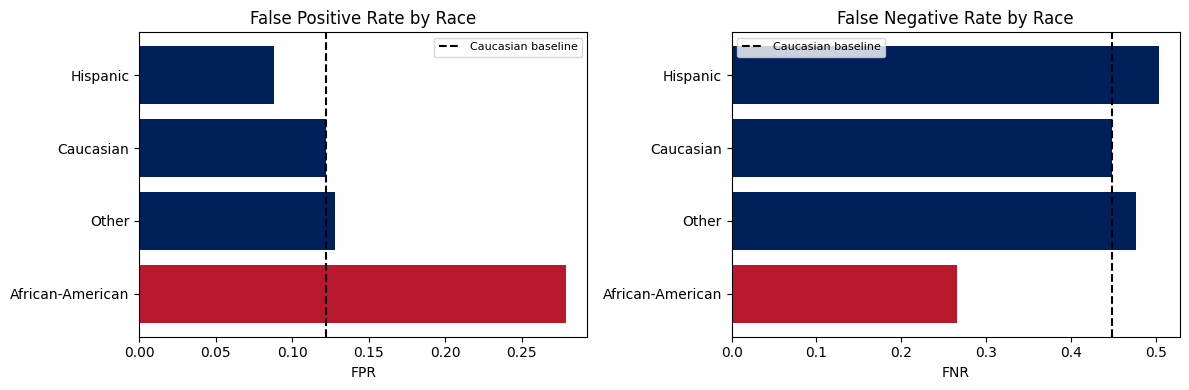

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
er_plot = er[er["n"] >= 50].sort_values("FPR", ascending=False)
navy, red = "#00205B", "#B8192C"
colors = [red if r == "African-American" else navy for r in er_plot["race"]]

for ax, metric, title in [
    (axes[0], "FPR", "False Positive Rate by Race"),
    (axes[1], "FNR", "False Negative Rate by Race")
]:
    ax.barh(er_plot["race"], er_plot[metric], color=colors)
    baseline = er_plot.loc[er_plot["race"] == "Caucasian", metric].iloc[0]
    ax.axvline(baseline, color="black", linestyle="--", label="Caucasian baseline", linewidth=1.5)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("error_rate_disparity.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 6: Compliance Memo (Lecture-03 Framing)

In [117]:
memo = """
**To:** Hypothetical Regulatory Reviewer  
**From:** Analyst, DNSC 6330  
**Subject:** COMPAS Disparate Impact Audit (Lecture 03 Framework)  
**Date:** April 2026

Using the Lecture 03 workflow, I audited disparate impact in the COMPAS pipeline with Caucasian (race) and Male (sex) as reference groups. This extends the Lecture 01-02 model workflow and reports both practical significance (AIR, ME, SMD, and error-rate gaps) and statistical significance (two-proportion z-tests), because either one alone can miss meaningful risk.

For race, the African-American selection rate was 0.517 versus 0.290 for Caucasian, giving AIR = 1.784 and ME = 0.227. Under the EEOC 80% rule, AIR is a practical threshold indicator; values near or below 0.80 can indicate potential adverse impact concern. The race selection-rate z-test gave p = 0.000000, indicating a statistically significant difference.

For sex, Female AIR relative to Male was 0.528, with ME = -0.208, and p = 0.000000. This also reflects a meaningful and statistically significant disparity pattern.

Error-rate analysis by race showed both FPR and FNR disparities relative to Caucasian defendants, with p = 0.000000 for FPR and p = 0.000000 for FNR. These represent different harms: FPR disparity reflects over-flagging among non-recidivists, while FNR disparity reflects under-identification among recidivists.

SMD was computed on model predicted probabilities and cross-checked with Solas. The largest race SMD and the Female-vs-Male SMD both supported the same direction of disparity seen in AIR/ME, adding score-level effect-size context.

Intersectional testing (race x sex) found worst-group AIR = 0.277 for Hispanic / Female (n = 82), confirming that aggregate metrics can hide concentrated subgroup burden.

Limitations include historical label/process bias, proxy-feature risk, and lower stability in smaller subgroups. Under burden-shifting logic, these findings should trigger documented business-necessity justification and review of less discriminatory alternatives before high-stakes deployment. These findings should be treated as governance signals, not one-time compliance checks.

Please let me know if you have any questions or would like me to run additional analyses.

Sincerly,
DNSC 6330 Analyst
"""

memo_word_count = len([w for w in memo.split() if any(ch.isalnum() for ch in w)])
print(f"Memo word count: {memo_word_count}")

display(Markdown(memo))


Memo word count: 311



**To:** Hypothetical Regulatory Reviewer  
**From:** Analyst, DNSC 6330  
**Subject:** COMPAS Disparate Impact Audit (Lecture 03 Framework)  
**Date:** April 2026

Using the Lecture 03 workflow, I audited disparate impact in the COMPAS pipeline with Caucasian (race) and Male (sex) as reference groups. This extends the Lecture 01-02 model workflow and reports both practical significance (AIR, ME, SMD, and error-rate gaps) and statistical significance (two-proportion z-tests), because either one alone can miss meaningful risk.

For race, the African-American selection rate was 0.517 versus 0.290 for Caucasian, giving AIR = 1.784 and ME = 0.227. Under the EEOC 80% rule, AIR is a practical threshold indicator; values near or below 0.80 can indicate potential adverse impact concern. The race selection-rate z-test gave p = 0.000000, indicating a statistically significant difference.

For sex, Female AIR relative to Male was 0.528, with ME = -0.208, and p = 0.000000. This also reflects a meaningful and statistically significant disparity pattern.

Error-rate analysis by race showed both FPR and FNR disparities relative to Caucasian defendants, with p = 0.000000 for FPR and p = 0.000000 for FNR. These represent different harms: FPR disparity reflects over-flagging among non-recidivists, while FNR disparity reflects under-identification among recidivists.

SMD was computed on model predicted probabilities and cross-checked with Solas. The largest race SMD and the Female-vs-Male SMD both supported the same direction of disparity seen in AIR/ME, adding score-level effect-size context.

Intersectional testing (race x sex) found worst-group AIR = 0.277 for Hispanic / Female (n = 82), confirming that aggregate metrics can hide concentrated subgroup burden.

Limitations include historical label/process bias, proxy-feature risk, and lower stability in smaller subgroups. Under burden-shifting logic, these findings should trigger documented business-necessity justification and review of less discriminatory alternatives before high-stakes deployment. These findings should be treated as governance signals, not one-time compliance checks.

Please let me know if you have any questions or would like me to run additional analyses.

Sincerly,
DNSC 6330 Analyst
